In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


In [3]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

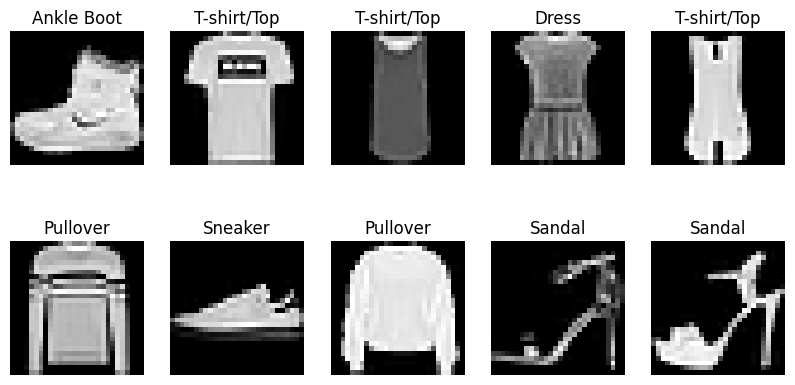

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [7]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [8]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

# First Pooling Layer
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),
                 activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128,
                activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10,
                activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.9202 - loss: 0.2135 - val_accuracy: 0.9061 - val_loss: 0.2577
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9242 - loss: 0.2011 - val_accuracy: 0.9102 - val_loss: 0.2557
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9267 - loss: 0.1945 - val_accuracy: 0.9062 - val_loss: 0.2645
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9315 - loss: 0.1826 - val_accuracy: 0.9125 - val_loss: 0.2580
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9344 - loss: 0.1745 - val_accuracy: 0.9134 - val_loss: 0.2580
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9365 - loss: 0.1670 - val_accuracy: 0.9081 - val_loss: 0.2649
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9398 - loss: 0.1603 - val_accuracy: 0.9127 - val_loss: 0.2598
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.9406 -

In [13]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9075 - loss: 0.2969
Test Loss: 0.29691165685653687
Test Accuracy: 0.9075000286102295


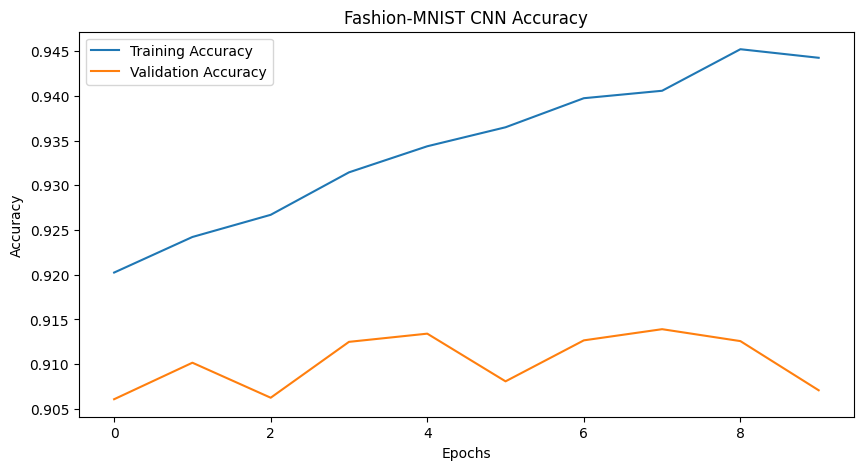

In [14]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fashion-MNIST CNN Accuracy')
plt.legend()

plt.show()

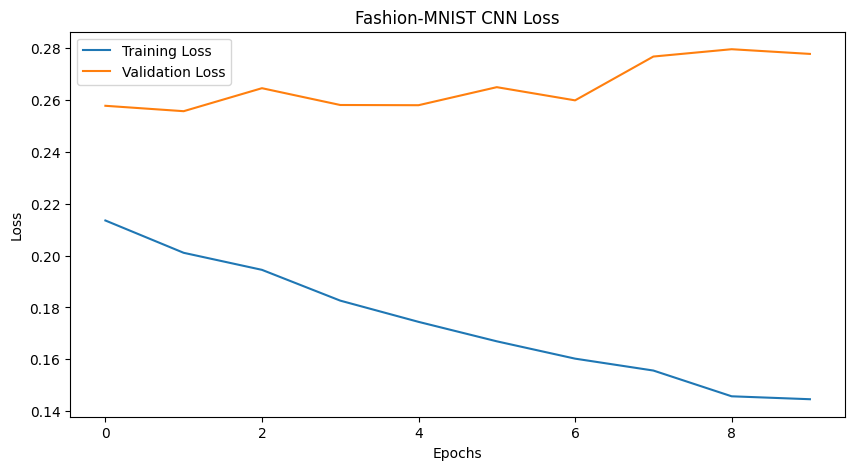

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Fashion-MNIST CNN Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


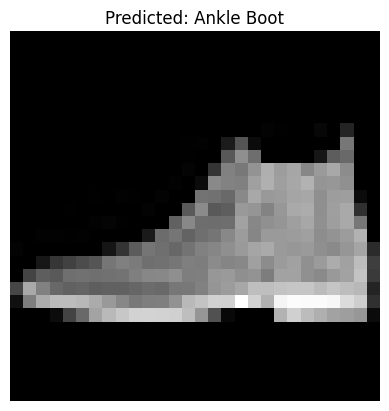

In [16]:
sample = X_test[0]

prediction = model.predict(
    sample.reshape(1,28,28,1)
)

predicted_class = np.argmax(prediction)

plt.imshow(sample.reshape(28,28),
           cmap='gray')

plt.title(
    f"Predicted: {class_names[predicted_class]}"
)

plt.axis('off')
plt.show()

Saving OIP (1).webp to OIP (1).webp


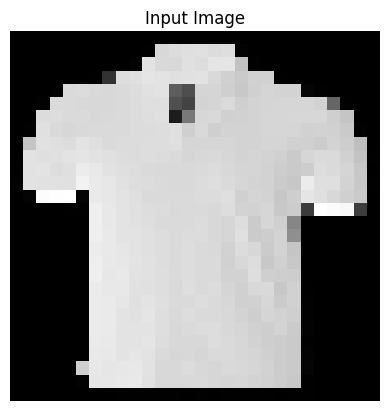

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Class: T-shirt/Top
Confidence Score: 99.88759 %


In [19]:
from google.colab import files
import cv2

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path,
                 cv2.IMREAD_GRAYSCALE)

# Resize
img = cv2.resize(img,(28,28))

# Invert if needed
img = 255 - img

# Normalize
img = img/255.0

# Display
plt.imshow(img,cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

# CNN Shape
img = img.reshape(1,28,28,1)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print("Predicted Class:",
      class_names[predicted_class])

print("Confidence Score:",
      np.max(prediction)*100,"%")